# Comprehensive Component Ablation — Memetic NAS Individual Module Contribution (3 × 3 Full Suite)

This notebook compares the **Full Proposed Algorithm (C0)** against each algorithmic module run **in isolation**, providing a direct measurement of each component's individual contribution to the overall search quality.

| ID | Variant | Description |
|---|---|---|
| C0 | `full_proposed` | Full proposed algorithm (all components active) |
| C1 | `moead_only` | MOEA/D decomposition only (K=5, random selection, no GA/PSO/SA) |
| C2 | `ga_only` | GA operator only (K=1, full calibrated params, no PSO/SA) |
| C3 | `pso_only` | PSO operator only (K=1, full calibrated params, no GA/SA) |
| C4 | `sa_only` | SA local refinement only (K=1, full calibrated params, no GA/PSO) |

**Isolation strategy:** Each component uses calibrated hyper-parameters from `configs/full_proposed.json`.  
**Coverage:** 3 datasets × 3 hardware = 9 (dataset × hardware) combinations  
**Statistics:** Wilcoxon rank-sum (Bonferroni-corrected, α = 0.05, 4 comparisons per combo)  
**Visuals:** Seaborn HV/IGD grids · Significance heatmap · Individual contribution ranking · 3×3 Pareto overlay · Overall ranking

In [1]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    PROJECT_ROOT = _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ranksums

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, calc_spacing, proxy_pareto,
)
from src.analysis.data_loader import (
    DATASETS, HARDWARE,
    load_ablation_archives as _load_ablation_archives,
    load_archives_glob,
)
from src.utils.pareto_math import compute_bounds, normalise_to_bounds

PROPOSED_DIR = PROJECT_ROOT / "results" / "proposed"
ABLATION_DIR = PROJECT_ROOT / "results" / "ablations"
OUT_DIR      = PROJECT_ROOT / "results" / "figures" / "component_ablation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":        150,
    "font.size":         10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Experiment catalogue ─────────────────────────────────────────────────────
EXPERIMENT_ORDER = [
    ("full_proposed", "C0: Full"),
    ("moead_only",    "C1: MOEA/D only"),
    ("ga_only",       "C2: GA only"),
    ("pso_only",      "C3: PSO only"),
    ("sa_only",       "C4: SA only"),
]
EXP_NAMES  = [n for n, _ in EXPERIMENT_ORDER]
EXP_LABELS = {n: l for n, l in EXPERIMENT_ORDER}
EXP_SHORT  = {n: l.split(": ")[1] for n, l in EXPERIMENT_ORDER}

COLORS = {
    "full_proposed": "#1f77b4",
    "moead_only":    "#ff7f0e",
    "ga_only":       "#2ca02c",
    "pso_only":      "#d62728",
    "sa_only":       "#9467bd",
}
PALETTE = {EXP_SHORT[n]: COLORS[n] for n in EXP_NAMES}

DS_LABEL = {
    "cifar10":        "CIFAR-10",
    "cifar100":       "CIFAR-100",
    "ImageNet16-120": "ImageNet-16",
}
HW_LABEL = {
    "edgegpu_latency": "EdgeGPU",
    "raspi4_latency":  "RPi-4",
    "eyeriss_latency": "Eyeriss",
}

REF = np.array([1.1, 1.1])

# ── Cache configuration ──────────────────────────────────────────────────────
CACHE_DIR          = PROJECT_ROOT / "results" / "cache"
CACHE_METRICS_ROOT = CACHE_DIR / "metrics"
CACHE_PARETO_ROOT  = CACHE_DIR / "pareto"
CACHE_METRICS_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_PARETO_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_METHODS = EXP_NAMES

# Set to True to ignore existing cache and recompute everything from scratch
FORCE_RECOMPUTE = False


def _metrics_cache_path(exp_name):
    path = CACHE_METRICS_ROOT / exp_name / "metrics.csv"
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def _pareto_cache_path(exp_name):
    path = CACHE_PARETO_ROOT / exp_name / "pareto.csv"
    path.parent.mkdir(parents=True, exist_ok=True)
    return path

print("Setup complete.")
print(f"Cache root       : {CACHE_DIR}")
print(f"Metrics root     : {CACHE_METRICS_ROOT}")
print(f"Pareto root      : {CACHE_PARETO_ROOT}")
for exp in CACHE_METHODS:
    print(f"  {exp}: metrics={_metrics_cache_path(exp).relative_to(PROJECT_ROOT)} pareto={_pareto_cache_path(exp).relative_to(PROJECT_ROOT)}")

PROJECT_ROOT = /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic


Setup complete.
Cache root       : /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache
Metrics root     : /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/metrics
Pareto root      : /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto
  full_proposed: metrics=results/cache/metrics/full_proposed/metrics.csv pareto=results/cache/pareto/full_proposed/pareto.csv
  moead_only: metrics=results/cache/metrics/moead_only/metrics.csv pareto=results/cache/pareto/moead_only/pareto.csv
  ga_only: metrics=results/cache/metrics/ga_only/metrics.csv pareto=results/cache/pareto/ga_only/pareto.csv
  pso_only: metrics=results/cache/metrics/pso_only/metrics.csv pareto=results/cache/pareto/pso_only/pareto.csv
  sa_only: metrics=results/cache/metrics/sa_only/metrics.csv pareto=results/cache/pareto/sa_only/pareto.csv


In [2]:
# ── Cell 2: Load/compute per-seed HV/IGD/Spacing → tidy DataFrame ─────────────
#
# On first run (or when FORCE_RECOMPUTE=True):
#   • loads raw archives from results/proposed/ and results/ablations/
#   • computes HV, IGD, Spacing per seed
#   • saves per-method caches under results/cache/metrics/<method>/metrics.csv
#
# On subsequent runs:
#   • reads per-method cache files directly (fast)
#   • reconstructs all_metrics dict in memory
#
# To force a full recompute: set FORCE_RECOMPUTE = True in Cell 1.

SHORT_ORDER = [EXP_SHORT[n] for n in EXP_NAMES]

def _reconstruct_all_metrics(df):
    """Rebuild the all_metrics[ds][hw][exp_name] = {hv, igd, spacing} dict
    from a tidy DataFrame loaded from CSV."""
    m = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
    for (dk, hk, en), grp in df.groupby(["ds_key", "hw_key", "exp_name"]):
        if dk not in m or hk not in m[dk]:
            continue
        g = grp.sort_values("Seed")
        m[dk][hk][en] = {
            "hv":      g["HV"].values,
            "igd":     g["IGD"].values,
            "spacing": g["Spacing"].values,
        }
    return m

# ─────────────────────────────────────────────────────────────────────────────
# FAST PATH — load from per-method cache
# ─────────────────────────────────────────────────────────────────────────────
CACHE_METRICS_PATHS = {name: _metrics_cache_path(name) for name in CACHE_METHODS}
_cached_names = [name for name, path in CACHE_METRICS_PATHS.items() if path.exists()]
_missing_names = [name for name in CACHE_METHODS if name not in _cached_names]

if not FORCE_RECOMPUTE and not _missing_names:
    print(f"\u2713  Cache hit — loading metrics from per-method cache:")
    for name, path in CACHE_METRICS_PATHS.items():
        print(f"   {name}: {path}")

    tidy_df = pd.concat(
        [pd.read_csv(path) for path in CACHE_METRICS_PATHS.values()],
        ignore_index=True,
    )
    tidy_df["Short"] = pd.Categorical(
        tidy_df["Short"], categories=SHORT_ORDER, ordered=True
    )
    all_metrics = _reconstruct_all_metrics(tidy_df)
    available   = None   # raw archives not loaded; Cell 9 uses per-method pareto cache

    _n_exp    = tidy_df["exp_name"].nunique()
    _n_combos = tidy_df.groupby(["ds_key", "hw_key"]).ngroups
    _seeds_avg = tidy_df.groupby(["ds_key", "hw_key", "exp_name"])["Seed"].count().mean()
    print(f"   {len(tidy_df)} rows  |  {_n_exp} experiments  |  "
          f"{_n_combos} combos  |  ~{_seeds_avg:.0f} seeds/exp/combo")
    print("\nTo force recomputation: set FORCE_RECOMPUTE = True in Cell 1.")
else:
    if FORCE_RECOMPUTE and _cached_names:
        print("\u26a0  FORCE_RECOMPUTE = True — ignoring existing per-method cache.\n")
    elif _missing_names:
        print(f"\u26a0  Missing per-method metric cache for: {', '.join(_missing_names)}")

    available    = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
    all_metrics  = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
    tidy_records = []

    _total_combos = len(DATASETS) * len(HARDWARE)
    _combo_idx    = 0

    print("Computing metrics from archives \u2026\n")
    for ds in DATASETS:
        for hw in HARDWARE:
            _combo_idx += 1
            combo_label = f"{DS_LABEL[ds]:<12} \u00d7 {HW_LABEL[hw]:<8}"
            print(f"  [{_combo_idx}/{_total_combos}] {combo_label} \u2026",
                  end=" ", flush=True)

            # Load full_proposed from results/proposed/
            proposed_dir = PROPOSED_DIR / ds / hw
            available[ds][hw]["full_proposed"] = (
                load_archives_glob(proposed_dir, "proposed_res_seed*.json")
                if proposed_dir.exists() else []
            )

            # Load isolated components from results/ablations/
            combo_dir = ABLATION_DIR / ds / hw
            for name in EXP_NAMES[1:]:
                available[ds][hw][name] = (
                    _load_ablation_archives(combo_dir, name)
                    if combo_dir.exists() else []
                )

            all_runs = [a for n in EXP_NAMES for a in available[ds][hw].get(n, [])]
            if not all_runs:
                print("SKIP (no data)")
                continue

            try:
                p_star = proxy_pareto(all_runs)
            except Exception as exc:
                print(f"SKIP (proxy_pareto: {exc})")
                continue

            bmin, brange = compute_bounds(p_star)
            p_star_n     = normalise_to_bounds(p_star, bmin, brange)

            for name in EXP_NAMES:
                arcs = available[ds][hw].get(name, [])
                hvs, igds, spacings = [], [], []
                for seed_i, run in enumerate(arcs):
                    pts   = archive_to_points(run)
                    front = get_pareto_front(pts)
                    nf    = normalise_to_bounds(front, bmin, brange)
                    hvs.append(calc_hv(nf, ref_point=REF))
                    igds.append(calc_igd(nf, p_star_n))
                    spacings.append(calc_spacing(nf))
                    tidy_records.append({
                        "Dataset":  DS_LABEL[ds],
                        "Hardware": HW_LABEL[hw],
                        "ds_key":   ds,
                        "hw_key":   hw,
                        "exp_name": name,
                        "Label":    EXP_LABELS[name],
                        "Short":    EXP_SHORT[name],
                        "Seed":     seed_i,
                        "HV":       hvs[-1],
                        "IGD":      igds[-1],
                        "Spacing":  spacings[-1],
                    })
                all_metrics[ds][hw][name] = {
                    "hv":      np.array(hvs),
                    "igd":     np.array(igds),
                    "spacing": np.array(spacings),
                }

            n_seeds = len(available[ds][hw].get("full_proposed", []))
            print(f"\u2713  ({n_seeds} seeds/exp)")

    tidy_df = pd.DataFrame(tidy_records)
    tidy_df["Short"] = pd.Categorical(
        tidy_df["Short"], categories=SHORT_ORDER, ordered=True
    )

    # ── Save per-method CSV caches ────────────────────────────────────────────
    for exp_name, grp in tidy_df.groupby("exp_name"):
        cache_path = _metrics_cache_path(exp_name)
        grp.to_csv(cache_path, index=False)
        print(f"\u2713  Saved metrics cache for {exp_name} → {cache_path}")

print(f"\nTidy DataFrame: {len(tidy_df)} rows with HV, IGD, Spacing per seed")

⚠  Missing per-method metric cache for: full_proposed, moead_only, ga_only, pso_only, sa_only
Computing metrics from archives …

  [1/9] CIFAR-10     × EdgeGPU  … 
Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

✓  (30 seeds/exp)
  [2/9] CIFAR-10     × RPi-4    … ✓  (30 seeds/exp)
  [3/9] CIFAR-10     × Eyeriss  … ✓  (30 seeds/exp)
  [4/9] CIFAR-100    × EdgeGPU  … ✓  (30 seeds/exp)
  [5/9] CIFAR-100    × RPi-4    … ✓  (30 seeds/exp)
  [6/9] CIFAR-100    × Eyeriss  … ✓  (30 seeds/exp)
  [7/9] ImageNet-16  × EdgeGPU  … ✓  (30 seeds/exp)
  [8/9] ImageNet-16  × RPi-4    … ✓  (30 seeds/exp)
  [9/9] ImageNet-16  × Eyeriss  … ✓  (30 seeds/exp)
✓  Saved metrics cache for full_proposed → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/metrics/full_proposed/metrics.csv
✓  Saved metrics cache for ga_only → /home/abdeslem/Fol

In [3]:
# ── Cell 3: Summary pivot table (mean HV/IGD across 9 combos) ────────────────
records = []
for ds in DATASETS:
    for hw in HARDWARE:
        for name in EXP_NAMES:
            m    = all_metrics[ds][hw].get(name, {})
            hvs  = m.get("hv",  np.array([]))
            igds = m.get("igd", np.array([]))
            records.append({
                "Dataset":    DS_LABEL[ds],
                "Hardware":   HW_LABEL[hw],
                "Experiment": EXP_LABELS[name],
                "exp_name":   name,
                "hv_mean":    hvs.mean()  if len(hvs)  else float("nan"),
                "hv_std":     hvs.std()   if len(hvs)  else float("nan"),
                "igd_mean":   igds.mean() if len(igds) else float("nan"),
                "igd_std":    igds.std()  if len(igds) else float("nan"),
                "n_seeds":    len(hvs),
            })

df_pivot = pd.DataFrame(records)

pivot_hv = df_pivot.pivot_table(
    index="Experiment",
    columns=["Dataset", "Hardware"],
    values="hv_mean",
    aggfunc="mean",
).reindex([EXP_LABELS[n] for n in EXP_NAMES])

pivot_igd = df_pivot.pivot_table(
    index="Experiment",
    columns=["Dataset", "Hardware"],
    values="igd_mean",
    aggfunc="mean",
).reindex([EXP_LABELS[n] for n in EXP_NAMES])

print("Mean Hypervolume \u2191 (9 combinations):\n")
display(pivot_hv.round(4).style
        .highlight_max(axis=0, color="#cce5ff")
        .set_caption("HV \u2191 \u2014 higher is better  |  C0: Full is the proposed algorithm"))

print("\nMean IGD \u2193 (9 combinations):\n")
display(pivot_igd.round(4).style
        .highlight_min(axis=0, color="#d4edda")
        .set_caption("IGD \u2193 \u2014 lower is better  |  C0: Full is the proposed algorithm"))

Mean Hypervolume ↑ (9 combinations):




Mean IGD ↓ (9 combinations):



In [4]:
# ── Cell 4: Wilcoxon rank-sum tests — C0 vs C1–C4 (Bonferroni-corrected) ─────
N_TESTS = len(EXP_NAMES) - 1  # 4 comparisons per combo

# Diagnostic: warn when seed count is too low
_seed_counts = [len(all_metrics[ds][hw].get("full_proposed", {}).get("hv", []))
                for ds in DATASETS for hw in HARDWARE]
_min_seeds = min(_seed_counts) if _seed_counts else 0
if _min_seeds < 2:
    print(
        f"\u26a0  Only {_min_seeds} seed(s) per combo detected for C0 (full_proposed).\n"
        "   Wilcoxon rank-sum needs \u2265 2 replicates per group to detect significance.\n"
        "   Run more seeds (--seeds 0..29) before interpreting p-values.\n"
    )

stat_records = []
for ds in DATASETS:
    for hw in HARDWARE:
        hv1 = all_metrics[ds][hw].get("full_proposed", {}).get("hv", np.array([]))
        if len(hv1) == 0:
            continue
        for name in EXP_NAMES[1:]:
            hv2 = all_metrics[ds][hw].get(name, {}).get("hv", np.array([]))
            if len(hv2) == 0:
                p_raw, stat = 1.0, 0.0
            else:
                try:
                    stat, p_raw = ranksums(hv1, hv2)
                except ValueError:
                    p_raw, stat = 1.0, 0.0
            p_bonf = min(p_raw * N_TESTS, 1.0)
            sig    = ("***" if p_bonf < 0.001 else
                      "**"  if p_bonf < 0.01  else
                      "*"   if p_bonf < 0.05  else "n.s.")
            stat_records.append({
                "Dataset":   DS_LABEL[ds],
                "Hardware":  HW_LABEL[hw],
                "Component": EXP_LABELS[name],
                "exp_name":  name,
                "ds_key":    ds,
                "hw_key":    hw,
                "W":         round(float(stat), 3),
                "p_raw":     float(p_raw),
                "p_bonf":    float(p_bonf),
                "sig":       sig,
                "delta_hv":  float(hv1.mean() - hv2.mean()) if len(hv2) else float("nan"),
            })

df_stats = pd.DataFrame(stat_records)

_expected_cols = [
    "Dataset", "Hardware", "Component", "exp_name", "ds_key", "hw_key",
    "W", "p_raw", "p_bonf", "sig", "delta_hv"
]
for _c in _expected_cols:
    if _c not in df_stats.columns:
        df_stats[_c] = np.nan

_idx = [EXP_LABELS[n] for n in EXP_NAMES[1:]]
_cols = pd.MultiIndex.from_product(
    [[DS_LABEL[d] for d in DATASETS], [HW_LABEL[h] for h in HARDWARE]],
    names=["Dataset", "Hardware"],
)

if df_stats.empty:
    pivot_sig = pd.DataFrame("n.s.", index=_idx, columns=_cols)
else:
    pivot_sig = (
        df_stats.pivot_table(
            index="Component",
            columns=["Dataset", "Hardware"],
            values="sig",
            aggfunc="first",
        )
        .reindex(index=_idx, columns=_cols)
        .fillna("n.s.")
    )

print("Wilcoxon rank-sum (C0 Full vs each isolated component)  Bonferroni-corrected:\n")
print(pivot_sig.to_string())
print("\n*** p<0.001   ** p<0.01   * p<0.05   n.s. = not significant")

if not df_stats.empty:
    pivot_delta = (
        df_stats.pivot_table(
            index="Component",
            columns=["Dataset", "Hardware"],
            values="delta_hv",
            aggfunc="mean",
        )
        .reindex(index=_idx, columns=_cols)
    )
    print("\nMean HV gain of C0 over each isolated component  (\u0394 = C0 \u2212 Ci, positive = C0 better):\n")
    print(pivot_delta.round(5).to_string())

Wilcoxon rank-sum (C0 Full vs each isolated component)  Bonferroni-corrected:

Dataset         CIFAR-10               CIFAR-100               ImageNet-16              
Hardware         EdgeGPU RPi-4 Eyeriss   EdgeGPU RPi-4 Eyeriss     EdgeGPU RPi-4 Eyeriss
Component                                                                               
C1: MOEA/D only        *  n.s.     ***        **  n.s.       *         ***  n.s.     ***
C2: GA only         n.s.  n.s.    n.s.      n.s.  n.s.    n.s.        n.s.  n.s.    n.s.
C3: PSO only         ***   ***     ***       ***   ***     ***         ***   ***     ***
C4: SA only         n.s.     *    n.s.      n.s.  n.s.    n.s.        n.s.  n.s.    n.s.

*** p<0.001   ** p<0.01   * p<0.05   n.s. = not significant

Mean HV gain of C0 over each isolated component  (Δ = C0 − Ci, positive = C0 better):

Dataset         CIFAR-10                   CIFAR-100                   ImageNet-16                  
Hardware         EdgeGPU    RPi-4  Eyeriss   Edg

/tmp/ipykernel_52735/504817695.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/504817695.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/504817695.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/504817695.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/504817695.py:39: UserWarning: set_ticklabels() 

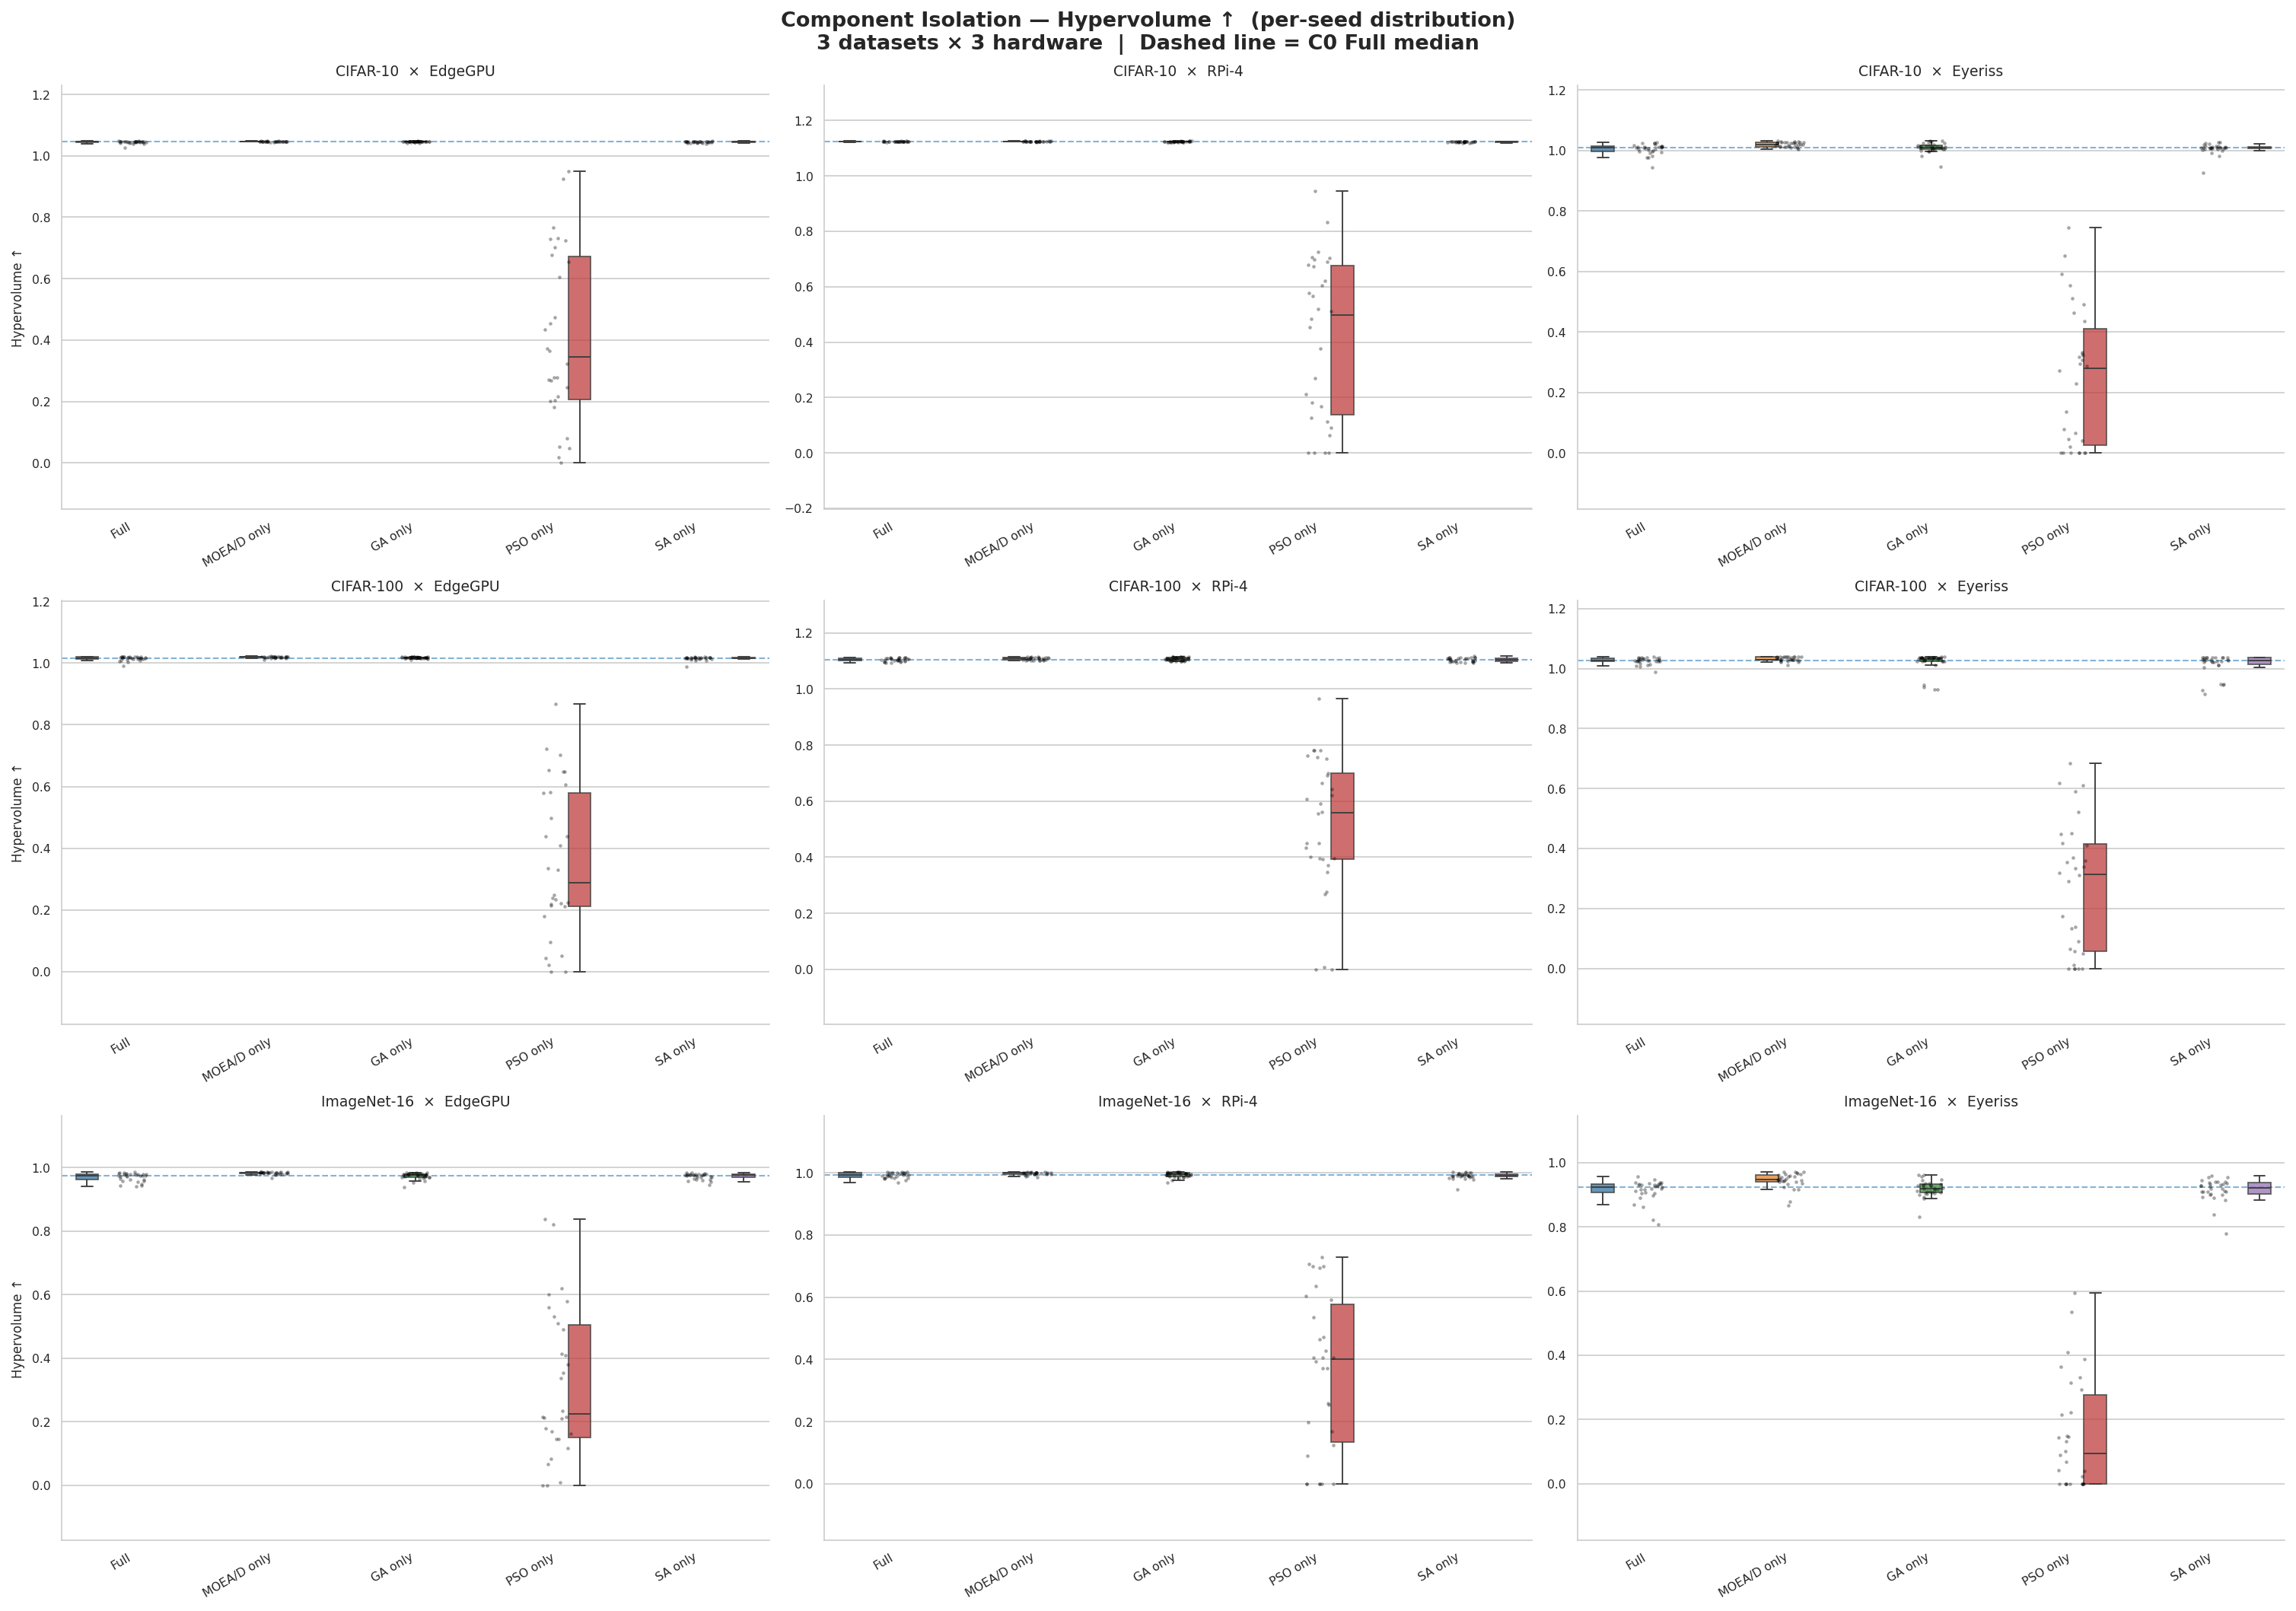

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_hv_3x3.pdf


In [5]:
# ── Cell 5: 3×3 Hypervolume seaborn boxplot + stripplot grid ─────────────────
fig_hv, axes_hv = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_hv.suptitle(
    "Component Isolation \u2014 Hypervolume \u2191  (per-seed distribution)\n"
    "3 datasets \u00d7 3 hardware  |  Dashed line = C0 Full median",
    fontsize=13, fontweight="bold",
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax  = axes_hv[r, c]
        sub = tidy_df[(tidy_df["ds_key"] == ds) & (tidy_df["hw_key"] == hw)]
        order = [s for s in SHORT_ORDER if s in sub["Short"].cat.categories
                 and len(sub[sub["Short"] == s]) > 0]

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=9)
            continue

        sns.boxplot(
            data=sub, x="Short", y="HV", hue="Short", order=order,
            palette=PALETTE, ax=ax, legend=False,
            showfliers=False, linewidth=0.9,
            boxprops=dict(alpha=0.75),
        )
        sns.stripplot(
            data=sub, x="Short", y="HV", order=order,
            color="black", size=2.2, alpha=0.35, jitter=True, ax=ax,
        )

        c0_med = sub[sub["exp_name"] == "full_proposed"]["HV"].median()
        ax.axhline(c0_med, color=COLORS["full_proposed"], lw=1.0,
                   ls="--", alpha=0.55, zorder=0)

        ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=9)
        ax.set_xlabel("")
        ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
        ax.set_ylabel("Hypervolume \u2191" if c == 0 else "", fontsize=8)
        ax.tick_params(axis="y", labelsize=7.5)

        # Zoom y-axis to data range so all boxes are clearly visible
        hv_vals = sub["HV"].dropna().values
        if len(hv_vals) > 1:
            lo, hi = np.percentile(hv_vals, [1, 99])
            span = max(hi - lo, 1e-6)
            ax.set_ylim(lo - span * 0.18, hi + span * 0.18)

save_hv = OUT_DIR / "component_hv_3x3.pdf"
plt.savefig(save_hv, bbox_inches="tight")
plt.show()
print(f"Saved: {save_hv}")


/tmp/ipykernel_52735/4013488603.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/4013488603.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/4013488603.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/4013488603.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
/tmp/ipykernel_52735/4013488603.py:39: UserWarning: set_ticklabe

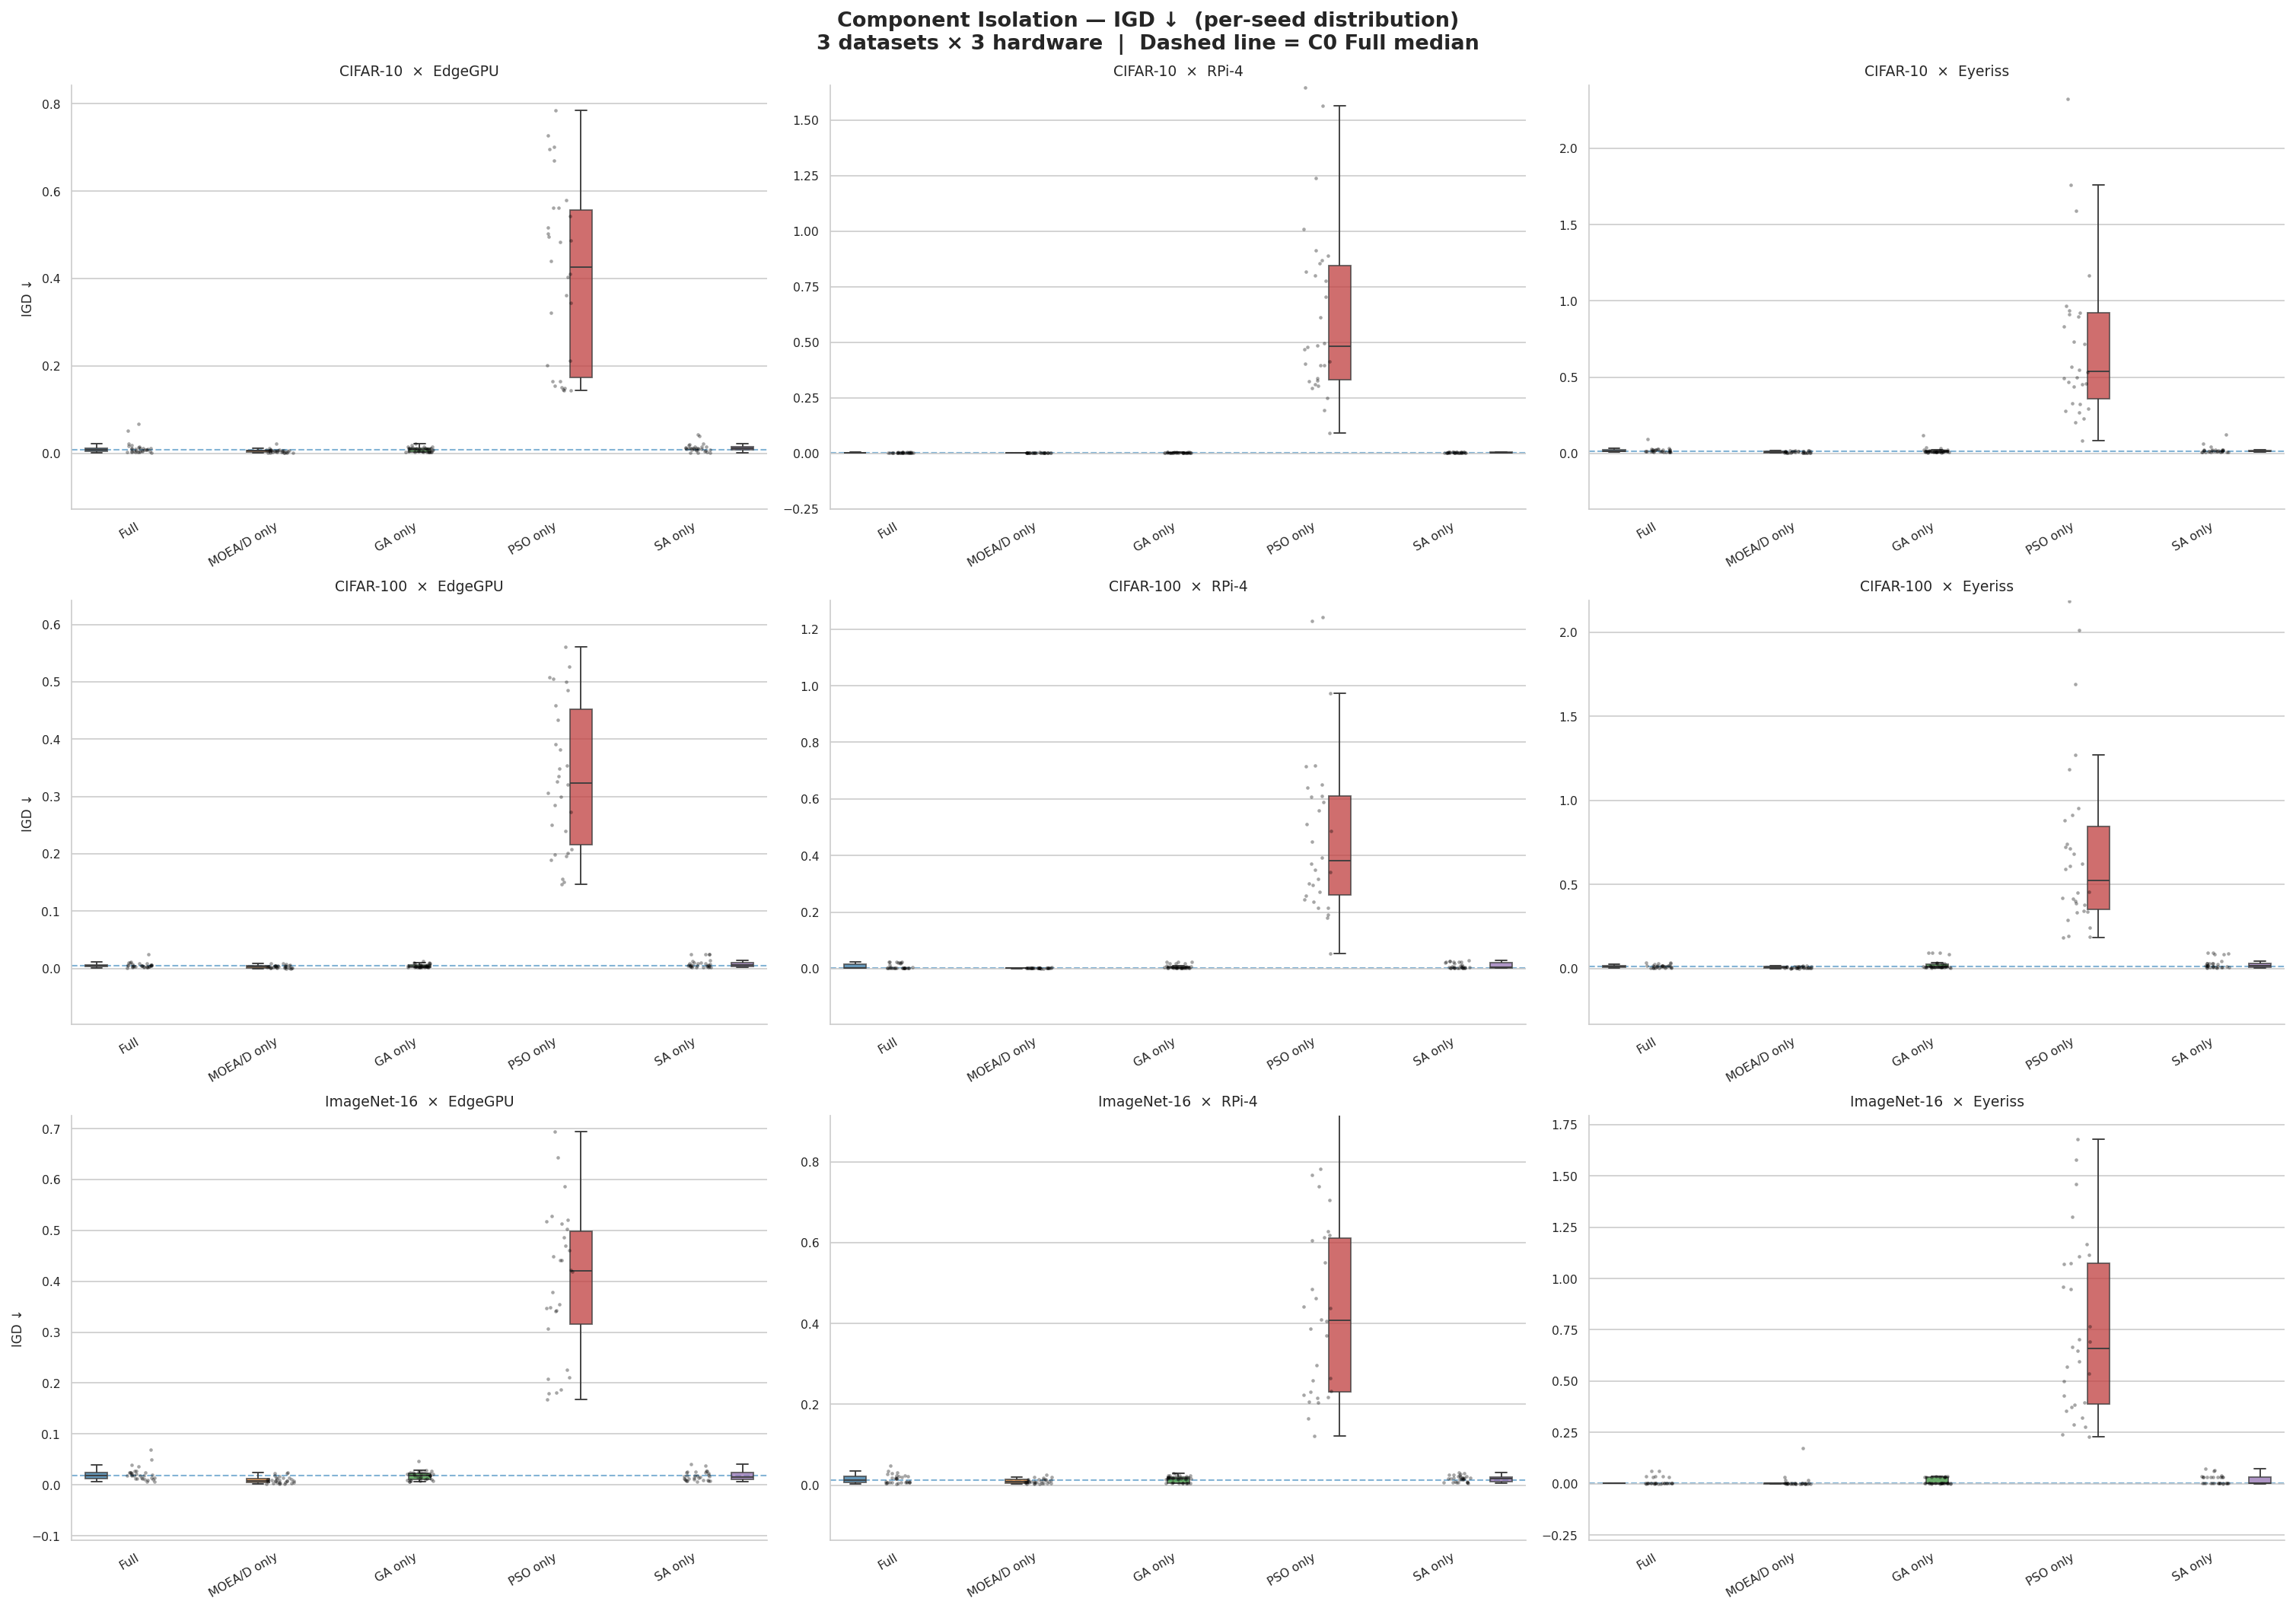

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_igd_3x3.pdf


In [6]:
# ── Cell 6: 3×3 IGD seaborn boxplot + stripplot grid ─────────────────────────
fig_igd, axes_igd = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_igd.suptitle(
    "Component Isolation \u2014 IGD \u2193  (per-seed distribution)\n"
    "3 datasets \u00d7 3 hardware  |  Dashed line = C0 Full median",
    fontsize=13, fontweight="bold",
)

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax  = axes_igd[r, c]
        sub = tidy_df[(tidy_df["ds_key"] == ds) & (tidy_df["hw_key"] == hw)]
        order = [s for s in SHORT_ORDER if s in sub["Short"].cat.categories
                 and len(sub[sub["Short"] == s]) > 0]

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=9)
            continue

        sns.boxplot(
            data=sub, x="Short", y="IGD", hue="Short", order=order,
            palette=PALETTE, ax=ax, legend=False,
            showfliers=False, linewidth=0.9,
            boxprops=dict(alpha=0.75),
        )
        sns.stripplot(
            data=sub, x="Short", y="IGD", order=order,
            color="black", size=2.2, alpha=0.35, jitter=True, ax=ax,
        )

        c0_med = sub[sub["exp_name"] == "full_proposed"]["IGD"].median()
        ax.axhline(c0_med, color=COLORS["full_proposed"], lw=1.0,
                   ls="--", alpha=0.55, zorder=0)

        ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=9)
        ax.set_xlabel("")
        ax.set_xticklabels(order, fontsize=7.5, rotation=30, ha="right")
        ax.set_ylabel("IGD \u2193" if c == 0 else "", fontsize=8)
        ax.tick_params(axis="y", labelsize=7.5)

        # Zoom y-axis to data range so all boxes are clearly visible
        igd_vals = sub["IGD"].dropna().values
        if len(igd_vals) > 1:
            lo, hi = np.percentile(igd_vals, [1, 99])
            span = max(hi - lo, 1e-6)
            ax.set_ylim(lo - span * 0.18, hi + span * 0.18)

save_igd = OUT_DIR / "component_igd_3x3.pdf"
plt.savefig(save_igd, bbox_inches="tight")
plt.show()
print(f"Saved: {save_igd}")


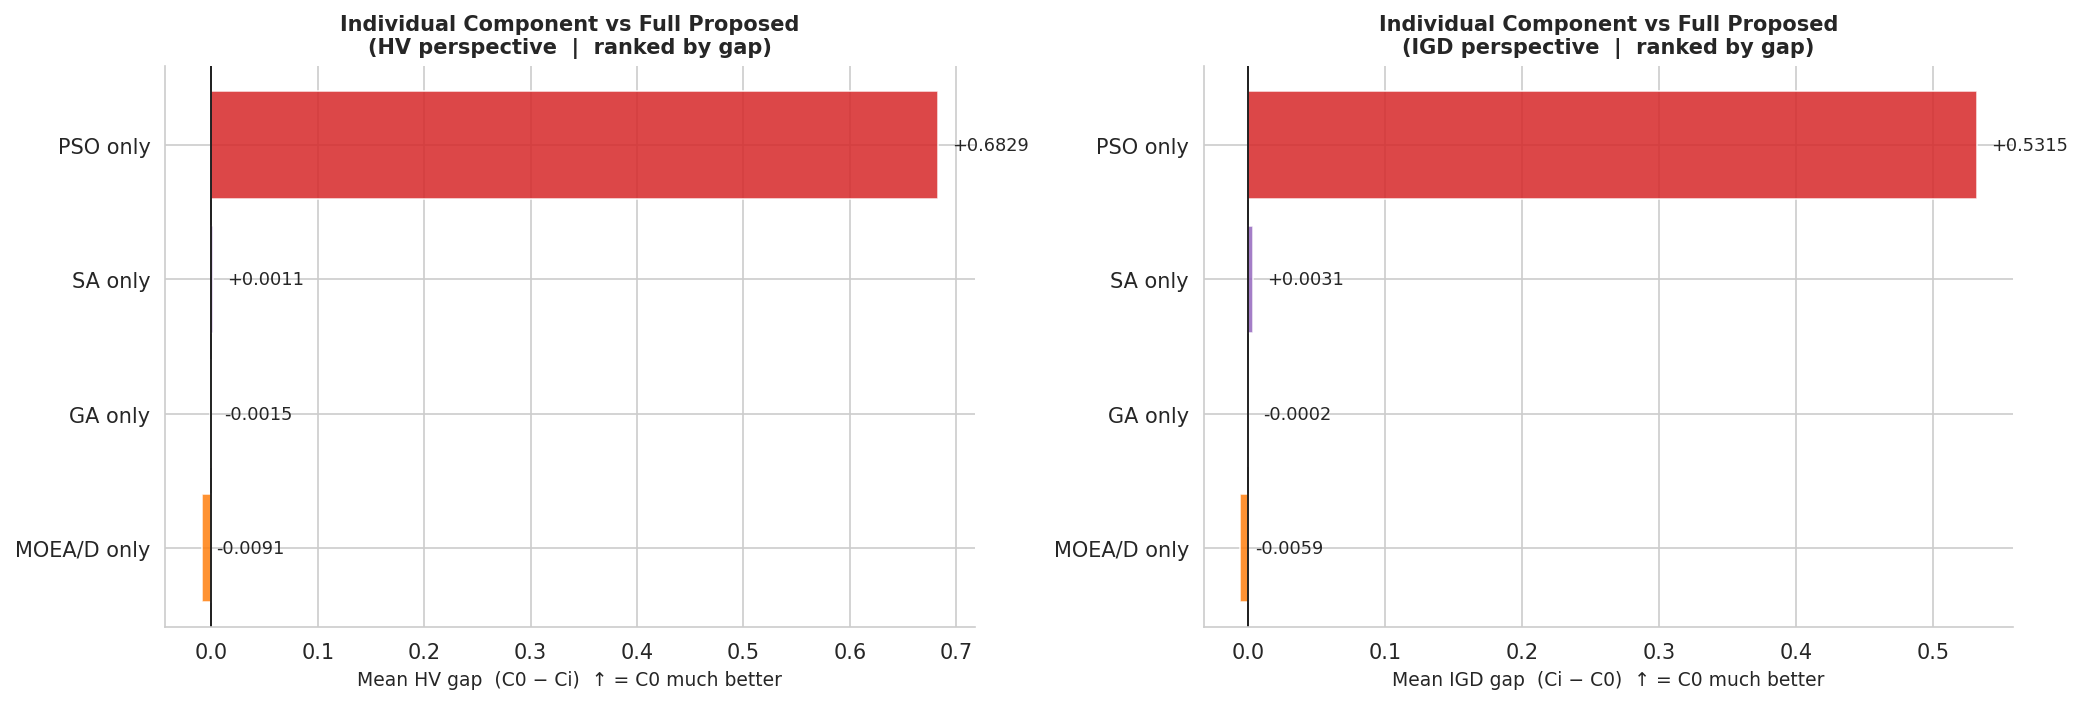

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_contribution_ranking.pdf

Ranking by HV gap (larger gap = C0 gains more over that single component):
      Component  delta_hv  delta_igd
   C3: PSO only  0.682850   0.531495
    C4: SA only  0.001060   0.003079
    C2: GA only -0.001541  -0.000176
C1: MOEA/D only -0.009065  -0.005873


In [7]:
# ── Cell 7: Individual component contribution ranking (HV gap + IGD gap vs C0) ─
contrib_records = []
for name in EXP_NAMES[1:]:
    for ds in DATASETS:
        for hw in HARDWARE:
            hv0  = all_metrics[ds][hw].get("full_proposed", {}).get("hv",  np.array([]))
            hvi  = all_metrics[ds][hw].get(name, {}).get("hv",  np.array([]))
            igd0 = all_metrics[ds][hw].get("full_proposed", {}).get("igd", np.array([]))
            igdi = all_metrics[ds][hw].get(name, {}).get("igd", np.array([]))
            if len(hv0) > 0 and len(hvi) > 0:
                contrib_records.append({
                    "Component": EXP_LABELS[name],
                    "Short":     EXP_SHORT[name],
                    "exp_name":  name,
                    "Dataset":   DS_LABEL[ds],
                    "Hardware":  HW_LABEL[hw],
                    "delta_hv":  float(hv0.mean() - hvi.mean()),
                    "delta_igd": float(
                        igdi.mean() - igd0.mean() if len(igd0) > 0 and len(igdi) > 0 else float("nan")
                    ),
                })

contrib_df = pd.DataFrame(contrib_records)

if contrib_df.empty:
    mean_contrib = pd.DataFrame({
        "Component": [EXP_LABELS[n] for n in EXP_NAMES[1:]],
        "Short":     [EXP_SHORT[n]  for n in EXP_NAMES[1:]],
        "exp_name":  EXP_NAMES[1:],
        "delta_hv":  [float("nan")] * len(EXP_NAMES[1:]),
        "delta_igd": [float("nan")] * len(EXP_NAMES[1:]),
    })
    _no_contrib_data = True
else:
    mean_contrib = (
        contrib_df.groupby(["exp_name", "Short", "Component"])[["delta_hv", "delta_igd"]]
        .mean()
        .reset_index()
        .sort_values("delta_hv", ascending=False)
    )
    _no_contrib_data = False

fig_c, axes_c = plt.subplots(1, 2, figsize=(14, 4.8))

if _no_contrib_data:
    for ax in axes_c:
        ax.text(0.5, 0.5,
                "No component data available\n(run scripts/run_component_baselines.py first)",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=11, color="gray")
        ax.set_xticks([]); ax.set_yticks([])
else:
    for ax, (metric, xlabel, title_sfx) in zip(axes_c, [
        ("delta_hv",  "Mean HV gap  (C0 \u2212 Ci)  \u2191 = C0 much better",  "HV perspective"),
        ("delta_igd", "Mean IGD gap  (Ci \u2212 C0)  \u2191 = C0 much better", "IGD perspective"),
    ]):
        values = mean_contrib[metric].fillna(0)
        bars = ax.barh(
            mean_contrib["Short"],
            values,
            color=[COLORS[n] for n in mean_contrib["exp_name"]],
            edgecolor="white", linewidth=0.8, alpha=0.85,
        )
        ax.axvline(0, color="black", lw=0.8)
        abs_max = float(mean_contrib[metric].dropna().abs().max()) if not mean_contrib[metric].dropna().empty else 0.0
        ref = abs_max if abs_max > 0 else 1.0
        for bar, val in zip(bars, values):
            ax.text(val + ref * 0.02, bar.get_y() + bar.get_height() / 2,
                    f"{val:+.4f}", va="center", fontsize=8.5)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_title(
            f"Individual Component vs Full Proposed\n({title_sfx}  |  ranked by gap)",
            fontweight="bold", fontsize=10,
        )
        ax.invert_yaxis()
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig_c.tight_layout()
save_c = OUT_DIR / "component_contribution_ranking.pdf"
plt.savefig(save_c, bbox_inches="tight")
plt.show()
print(f"Saved: {save_c}")
if not _no_contrib_data:
    print("\nRanking by HV gap (larger gap = C0 gains more over that single component):")
    print(mean_contrib[["Component", "delta_hv", "delta_igd"]].to_string(index=False))

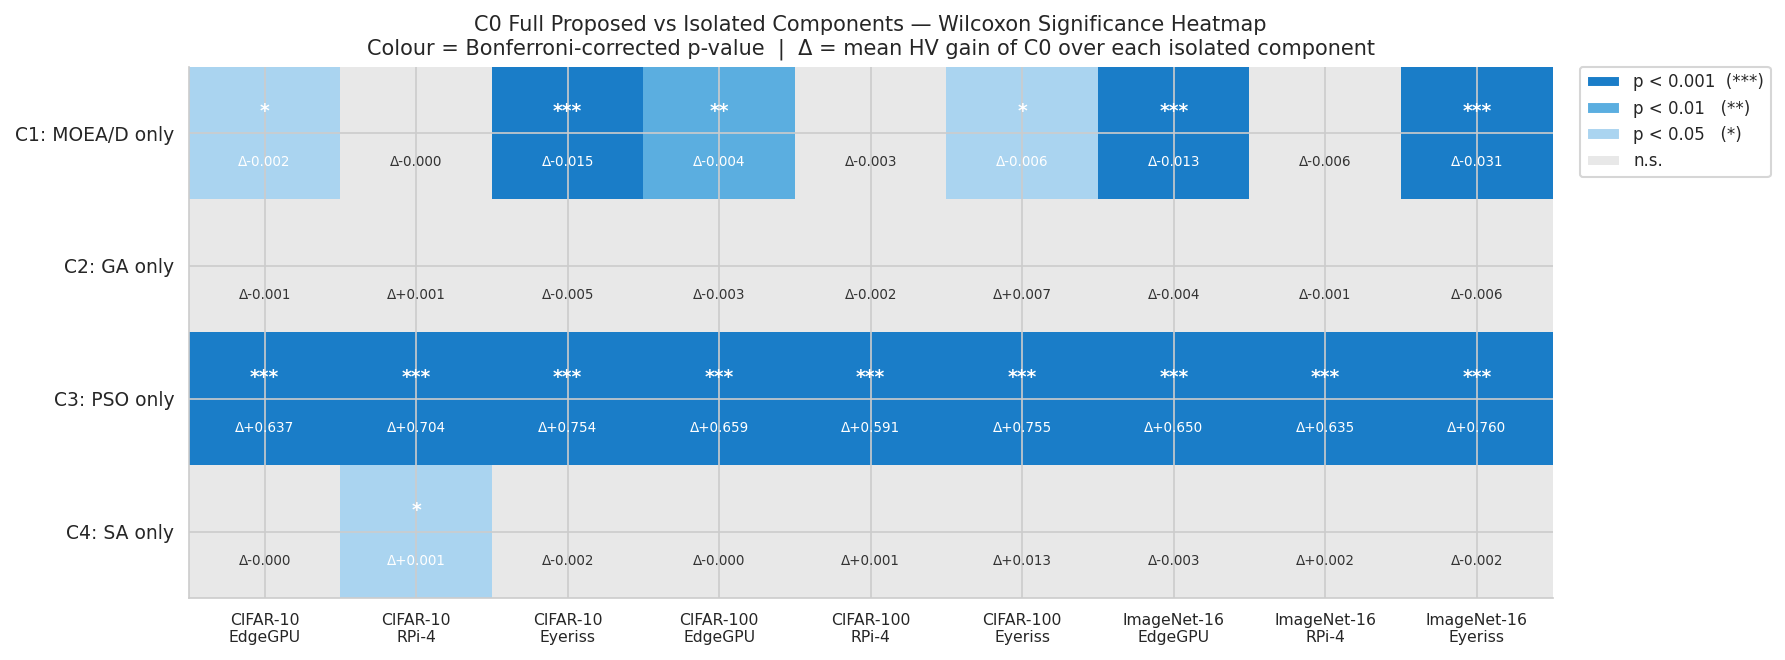

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_significance_heatmap.pdf


In [8]:
# ── Cell 8: Significance heatmap (component × dataset/hardware combo) ─────────
from matplotlib.colors import ListedColormap, BoundaryNorm

component_lbls = [EXP_LABELS[n] for n in EXP_NAMES[1:]]
combo_lbls     = [f"{DS_LABEL[ds]}\n{HW_LABEL[hw]}"
                  for ds in DATASETS for hw in HARDWARE]

p_matrix     = np.ones((len(component_lbls), len(combo_lbls)))
delta_matrix = np.zeros_like(p_matrix)

for j, (ds, hw) in enumerate([(d, h) for d in DATASETS for h in HARDWARE]):
    for i, name in enumerate(EXP_NAMES[1:]):
        row = df_stats[(df_stats["ds_key"] == ds) &
                       (df_stats["hw_key"] == hw) &
                       (df_stats["exp_name"] == name)]
        if not row.empty:
            p_matrix[i, j]     = row.iloc[0]["p_bonf"]
            delta_matrix[i, j] = row.iloc[0]["delta_hv"]

nr, nc = p_matrix.shape

level_matrix = np.zeros((nr, nc), dtype=int)
level_matrix[p_matrix < 0.05]  = 1
level_matrix[p_matrix < 0.01]  = 2
level_matrix[p_matrix < 0.001] = 3

level_colors = ["#e8e8e8", "#aad4f0", "#5baee0", "#1a7dc8"]
cmap = ListedColormap(level_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig_h, ax_h = plt.subplots(figsize=(14, 4.5))
ax_h.imshow(level_matrix, cmap=cmap, norm=norm, aspect="auto")

for i in range(nr):
    for j in range(nc):
        lv        = level_matrix[i, j]
        txt_color = "white" if lv > 0 else "#333333"
        stars     = ("***" if lv == 3 else "**" if lv == 2 else "*" if lv == 1 else "")
        if stars:
            ax_h.text(j, i - 0.16, stars,
                      ha="center", va="center",
                      fontsize=9, fontweight="bold", color=txt_color)
        ax_h.text(j, i + 0.22, f"\u0394{delta_matrix[i, j]:+.3f}",
                  ha="center", va="center", fontsize=6.5, color=txt_color)

ax_h.set_xticks(range(nc))
ax_h.set_xticklabels(combo_lbls, fontsize=7.5)
ax_h.set_yticks(range(nr))
ax_h.set_yticklabels(component_lbls, fontsize=9)
ax_h.set_title(
    "C0 Full Proposed vs Isolated Components \u2014 Wilcoxon Significance Heatmap\n"
    "Colour = Bonferroni-corrected p-value  |  \u0394 = mean HV gain of C0 over each isolated component",
    fontsize=10,
)

legend_patches = [
    mpatches.Patch(facecolor="#1a7dc8", label="p < 0.001  (***)"),
    mpatches.Patch(facecolor="#5baee0", label="p < 0.01   (**)"),
    mpatches.Patch(facecolor="#aad4f0", label="p < 0.05   (*)"),
    mpatches.Patch(facecolor="#e8e8e8", label="n.s."),
]
ax_h.legend(handles=legend_patches, loc="upper left",
            bbox_to_anchor=(1.02, 1.0), fontsize=8, borderaxespad=0)
fig_h.tight_layout(rect=[0, 0, 0.86, 1])
save_hm = OUT_DIR / "component_significance_heatmap.pdf"
plt.savefig(save_hm, bbox_inches="tight")
plt.show()
print(f"Saved: {save_hm}")

⚠  Missing per-method pareto cache for: full_proposed, moead_only, ga_only, pso_only, sa_only
Building aggregate Pareto fronts from archives … ✓  Saved pareto cache for full_proposed → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto/full_proposed/pareto.csv
✓  Saved pareto cache for moead_only → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto/moead_only/pareto.csv
✓  Saved pareto cache for ga_only → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto/ga_only/pareto.csv
✓  Saved pareto cache for pso_only → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto/pso_only/pareto.csv
✓  Saved pareto cache for sa_only → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/cache/pareto/sa_only/pareto.csv


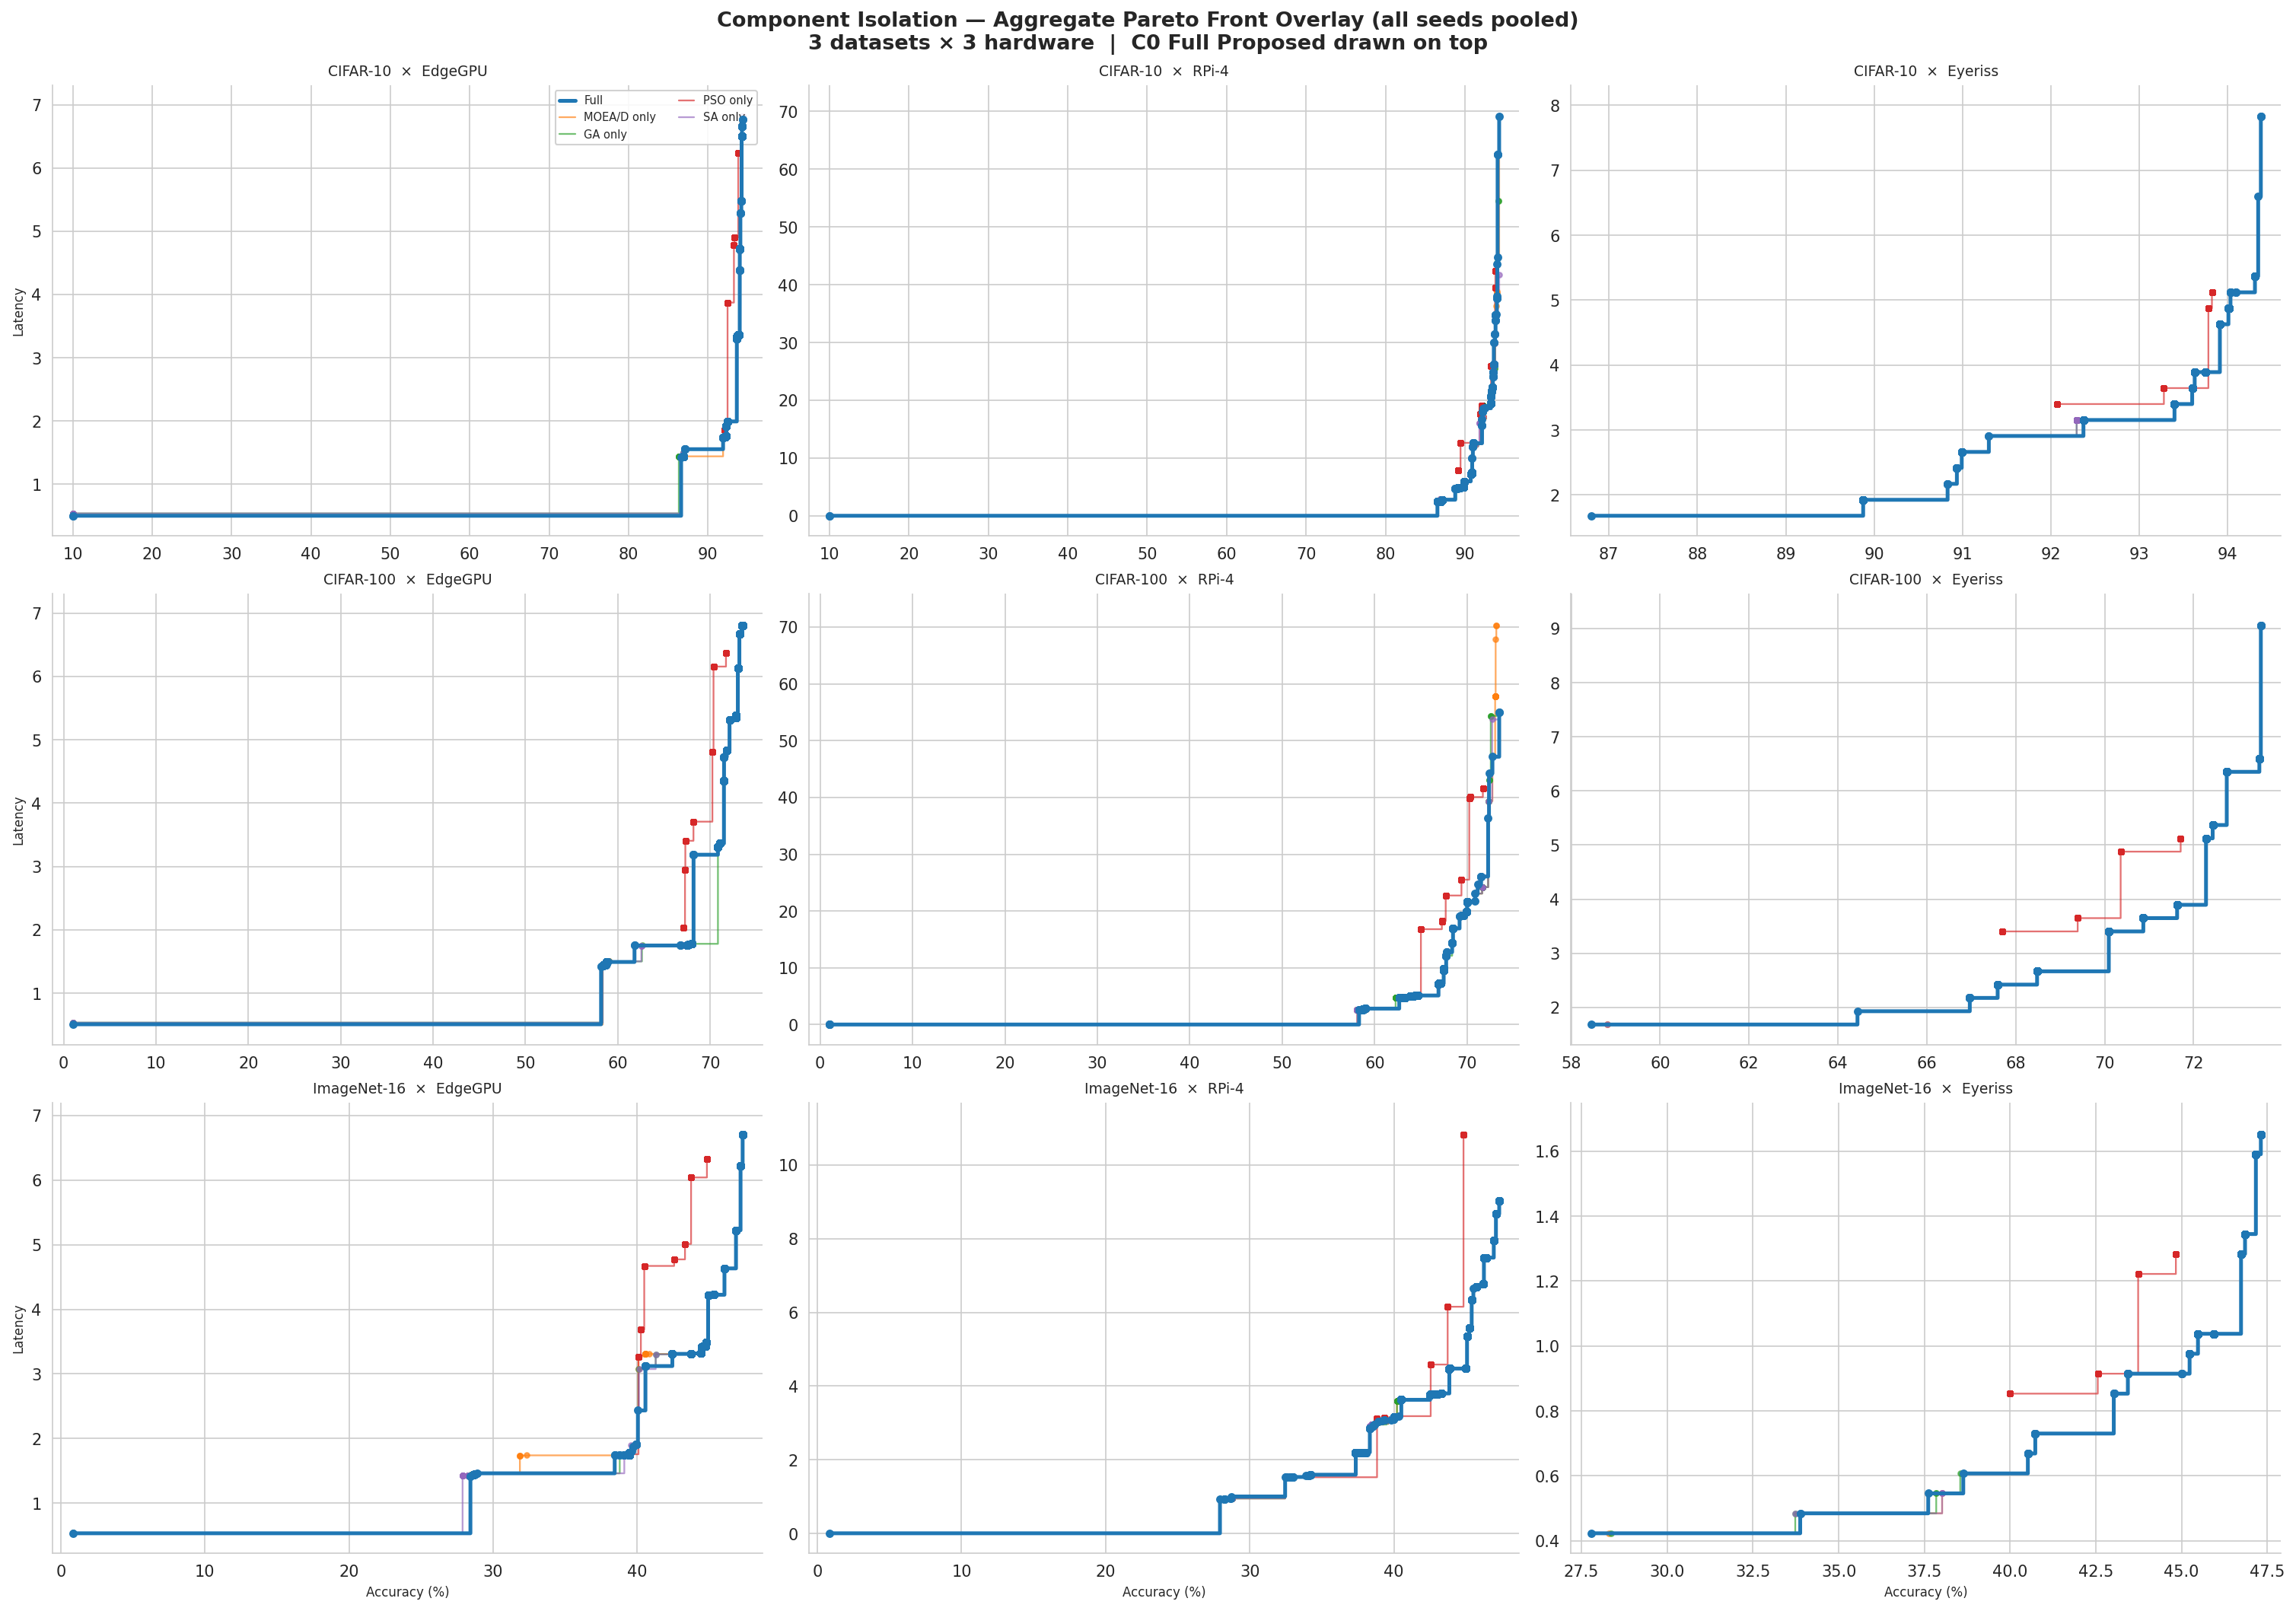

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_pareto_3x3.pdf


In [9]:
# ── Cell 9: 3×3 Aggregate Pareto front overlay (C0 drawn on top) ─────────────
#
# Aggregate Pareto fronts are cached per experiment method under
# results/cache/pareto/<method>/pareto.csv so any notebook can reuse them.

def _load_or_build_pareto_cache():
    """Return pareto_data[ds_key][hw_key][exp_name] = (acc_array, lat_array).
    Loads from per-method pareto cache if available, otherwise builds from raw
    `available` archives and saves per-method cache files."""

    cache_paths = {name: _pareto_cache_path(name) for name in CACHE_METHODS}
    cached_names = [name for name, path in cache_paths.items() if path.exists()]
    missing_names = [name for name in cache_paths if name not in cached_names]

    if not FORCE_RECOMPUTE and not missing_names:
        print(f"\u2713  Loading cached Pareto fronts from per-method cache:")
        for name, path in cache_paths.items():
            print(f"   {name}: {path}")

        pf = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
        for name, path in cache_paths.items():
            _df = pd.read_csv(path)
            for (dk, hk, en), grp in _df.groupby(["ds_key", "hw_key", "exp_name"]):
                if dk in pf and hk in pf[dk]:
                    order = np.argsort(grp["acc"].values)
                    pf[dk][hk][en] = (grp["acc"].values[order], grp["lat"].values[order])
        return pf

    if available is None:
        print(
            "\u26a0  No complete pareto cache found and raw archives were not loaded.\n"
            f"   missing methods: {', '.join(missing_names)}\n"
            "   Delete the per-method cache files (or set FORCE_RECOMPUTE=True)\n"
            "   and rerun Cell 2 to rebuild both caches."
        )
        return {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}

    if FORCE_RECOMPUTE and cached_names:
        print("\u26a0  FORCE_RECOMPUTE = True — rebuilding per-method pareto cache.\n")
    elif missing_names:
        print(f"\u26a0  Missing per-method pareto cache for: {', '.join(missing_names)}")

    print("Building aggregate Pareto fronts from archives \u2026", end=" ", flush=True)
    pf = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
    method_records = {name: [] for name in cache_paths}

    for ds in DATASETS:
        for hw in HARDWARE:
            for name in CACHE_METHODS:
                arcs = available[ds][hw].get(name, [])
                if not arcs:
                    continue
                try:
                    pts_all = np.vstack([archive_to_points(a) for a in arcs])
                except ValueError:
                    continue
                front = get_pareto_front(pts_all)
                acc   = -front[:, 0]
                lat   =  front[:, 1]
                order = np.argsort(acc)
                acc, lat = acc[order], lat[order]
                pf[ds][hw][name] = (acc, lat)
                for a_val, l_val in zip(acc, lat):
                    method_records[name].append({
                        "ds_key":   ds,
                        "hw_key":   hw,
                        "exp_name": name,
                        "acc":      a_val,
                        "lat":      l_val,
                    })

    for name, records in method_records.items():
        cache_path = cache_paths[name]
        pd.DataFrame(records).to_csv(cache_path, index=False)
        print(f"\u2713  Saved pareto cache for {name} → {cache_path}")

    return pf

_pareto_data = _load_or_build_pareto_cache()

# ── Draw 3×3 grid ─────────────────────────────────────────────────────────────
fig_p, axes_p = plt.subplots(3, 3, figsize=(20, 14), constrained_layout=True)
fig_p.suptitle(
    "Component Isolation \u2014 Aggregate Pareto Front Overlay (all seeds pooled)\n"
    "3 datasets \u00d7 3 hardware  |  C0 Full Proposed drawn on top",
    fontsize=13, fontweight="bold",
)

legend_built = False

for r, ds in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax = axes_p[r, c]

        lines = []
        all_acc_list = []
        all_lat_list = []

        for name in CACHE_METHODS:
            entry = _pareto_data[ds][hw].get(name)
            if entry is None:
                continue
            acc, lat = entry
            all_acc_list.append(acc)
            all_lat_list.append(lat)
            lines.append((name, acc, lat))

        if not lines:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=8)
            continue

        x_all = np.concatenate(all_acc_list)
        y_all = np.concatenate(all_lat_list)
        xrng = max(x_all.max() - x_all.min(), 0.1)
        yrng = max(y_all.max() - y_all.min(), 1e-6)
        ax.set_xlim(x_all.min() - xrng * 0.03, x_all.max() + xrng * 0.03)
        ax.set_ylim(y_all.min() - yrng * 0.05, y_all.max() + yrng * 0.08)

        for name, acc, lat in lines:
            is_c0 = (name == "full_proposed")
            ax.step(acc, lat, where="post",
                    color=COLORS[name],
                    linewidth=2.4 if is_c0 else 1.1,
                    alpha=1.0 if is_c0 else 0.65,
                    label=EXP_SHORT[name],
                    zorder=10 if is_c0 else 4)
            ax.scatter(acc, lat,
                       s=18 if is_c0 else 10,
                       color=COLORS[name],
                       alpha=1.0 if is_c0 else 0.65,
                       zorder=11 if is_c0 else 5)

        ax.set_title(f"{DS_LABEL[ds]}  \u00d7  {HW_LABEL[hw]}", fontsize=9)
        if c == 0:
            ax.set_ylabel("Latency", fontsize=8)
        if r == 2:
            ax.set_xlabel("Accuracy (%)", fontsize=8)
        if not legend_built:
            ax.legend(fontsize=7, loc="upper right", ncol=2,
                      framealpha=0.88, handlelength=1.4)
            legend_built = True

save_p = OUT_DIR / "component_pareto_3x3.pdf"
plt.savefig(save_p, bbox_inches="tight")
plt.show()
print(f"Saved: {save_p}")

In [10]:
# ── Cell 10: Overall Algorithm Ranking — HV · IGD · Spacing ──────────────────
#
# Ranks C0 (full proposed) against C1–C4 (isolated components).
# Metric conventions:
#   HV      ↑  rank 1 = highest mean HV
#   IGD     ↓  rank 1 = lowest  mean IGD
#   Spacing ↓  rank 1 = lowest  mean Spacing  (uniform front distribution)
#   Overall    rank = mean of the three individual ranks (lower = better)

summary = (
    tidy_df.groupby(["exp_name", "Label", "Short"])[["HV", "IGD", "Spacing"]]
    .mean()
    .reset_index()
)

summary["Rank_HV"]      = summary["HV"].rank(ascending=False).astype(int)
summary["Rank_IGD"]     = summary["IGD"].rank(ascending=True).astype(int)
summary["Rank_Spacing"] = summary["Spacing"].rank(ascending=True).astype(int)
summary["Rank_Overall"] = (
    (summary["Rank_HV"] + summary["Rank_IGD"] + summary["Rank_Spacing"]) / 3
)
summary = summary.sort_values("Rank_Overall").reset_index(drop=True)

rank_display = summary[[
    "Label", "HV", "IGD", "Spacing",
    "Rank_HV", "Rank_IGD", "Rank_Spacing", "Rank_Overall"
]].copy()
rank_display.columns = [
    "Algorithm", "HV \u2191 (mean)", "IGD \u2193 (mean)", "Spacing \u2193 (mean)",
    "Rank HV", "Rank IGD", "Rank Spacing", "Overall Rank"
]
rank_display.index = rank_display.index + 1

print("=" * 72)
print("ALGORITHM RANKING  (averaged over all 9 dataset \u00d7 hardware combos)")
print("C0 = Full proposed   C1\u2013C4 = isolated single components")
print("=" * 72)
display(
    rank_display.style
    .format({
        "HV \u2191 (mean)":      "{:.5f}",
        "IGD \u2193 (mean)":     "{:.5f}",
        "Spacing \u2193 (mean)": "{:.5f}",
        "Overall Rank":     "{:.2f}",
    })
    .highlight_min(subset=["Rank HV", "Rank IGD", "Rank Spacing", "Overall Rank"],
                   color="#cce5ff")
    .set_caption(
        "Rank 1 = best  |  HV \u2191 higher is better  |  "
        "IGD \u2193 & Spacing \u2193 lower is better  |  Overall = mean of three ranks"
    )
)

print("\nFinal order (best \u2192 worst):")
for pos, row in rank_display.iterrows():
    s = summary.iloc[pos - 1]
    print(f"  {pos}. {row['Algorithm']:<20}  "
          f"HV={row['HV \u2191 (mean)']:.5f}  IGD={row['IGD \u2193 (mean)']:.5f}  "
          f"Spacing={row['Spacing \u2193 (mean)']:.5f}  "
          f"[ranks: HV={int(s['Rank_HV'])} "
          f"IGD={int(s['Rank_IGD'])} "
          f"Spacing={int(s['Rank_Spacing'])} "
          f"\u2192 Overall={row['Overall Rank']:.2f}]")

ALGORITHM RANKING  (averaged over all 9 dataset × hardware combos)
C0 = Full proposed   C1–C4 = isolated single components


,Algorithm,HV ↑ (mean),IGD ↓ (mean),Spacing ↓ (mean),Rank HV,Rank IGD,Rank Spacing,Overall Rank
1,C1: MOEA/D only,1.03065,0.00666,0.03367,1,1,4,2.00
2,C0: Full,1.02159,0.01253,0.02644,3,3,3,3.00
3,C2: GA only,1.02313,0.01236,0.05547,2,2,5,3.00
4,C4: SA only,1.02053,0.01561,0.02170,4,4,2,3.33
5,C3: PSO only,0.33874,0.54403,0.00000,5,5,1,3.67



Final order (best → worst):
  1. C1: MOEA/D only       HV=1.03065  IGD=0.00666  Spacing=0.03367  [ranks: HV=1 IGD=1 Spacing=4 → Overall=2.00]
  2. C0: Full              HV=1.02159  IGD=0.01253  Spacing=0.02644  [ranks: HV=3 IGD=3 Spacing=3 → Overall=3.00]
  3. C2: GA only           HV=1.02313  IGD=0.01236  Spacing=0.05547  [ranks: HV=2 IGD=2 Spacing=5 → Overall=3.00]
  4. C4: SA only           HV=1.02053  IGD=0.01561  Spacing=0.02170  [ranks: HV=4 IGD=4 Spacing=2 → Overall=3.33]
  5. C3: PSO only          HV=0.33874  IGD=0.54403  Spacing=0.00000  [ranks: HV=5 IGD=5 Spacing=1 → Overall=3.67]


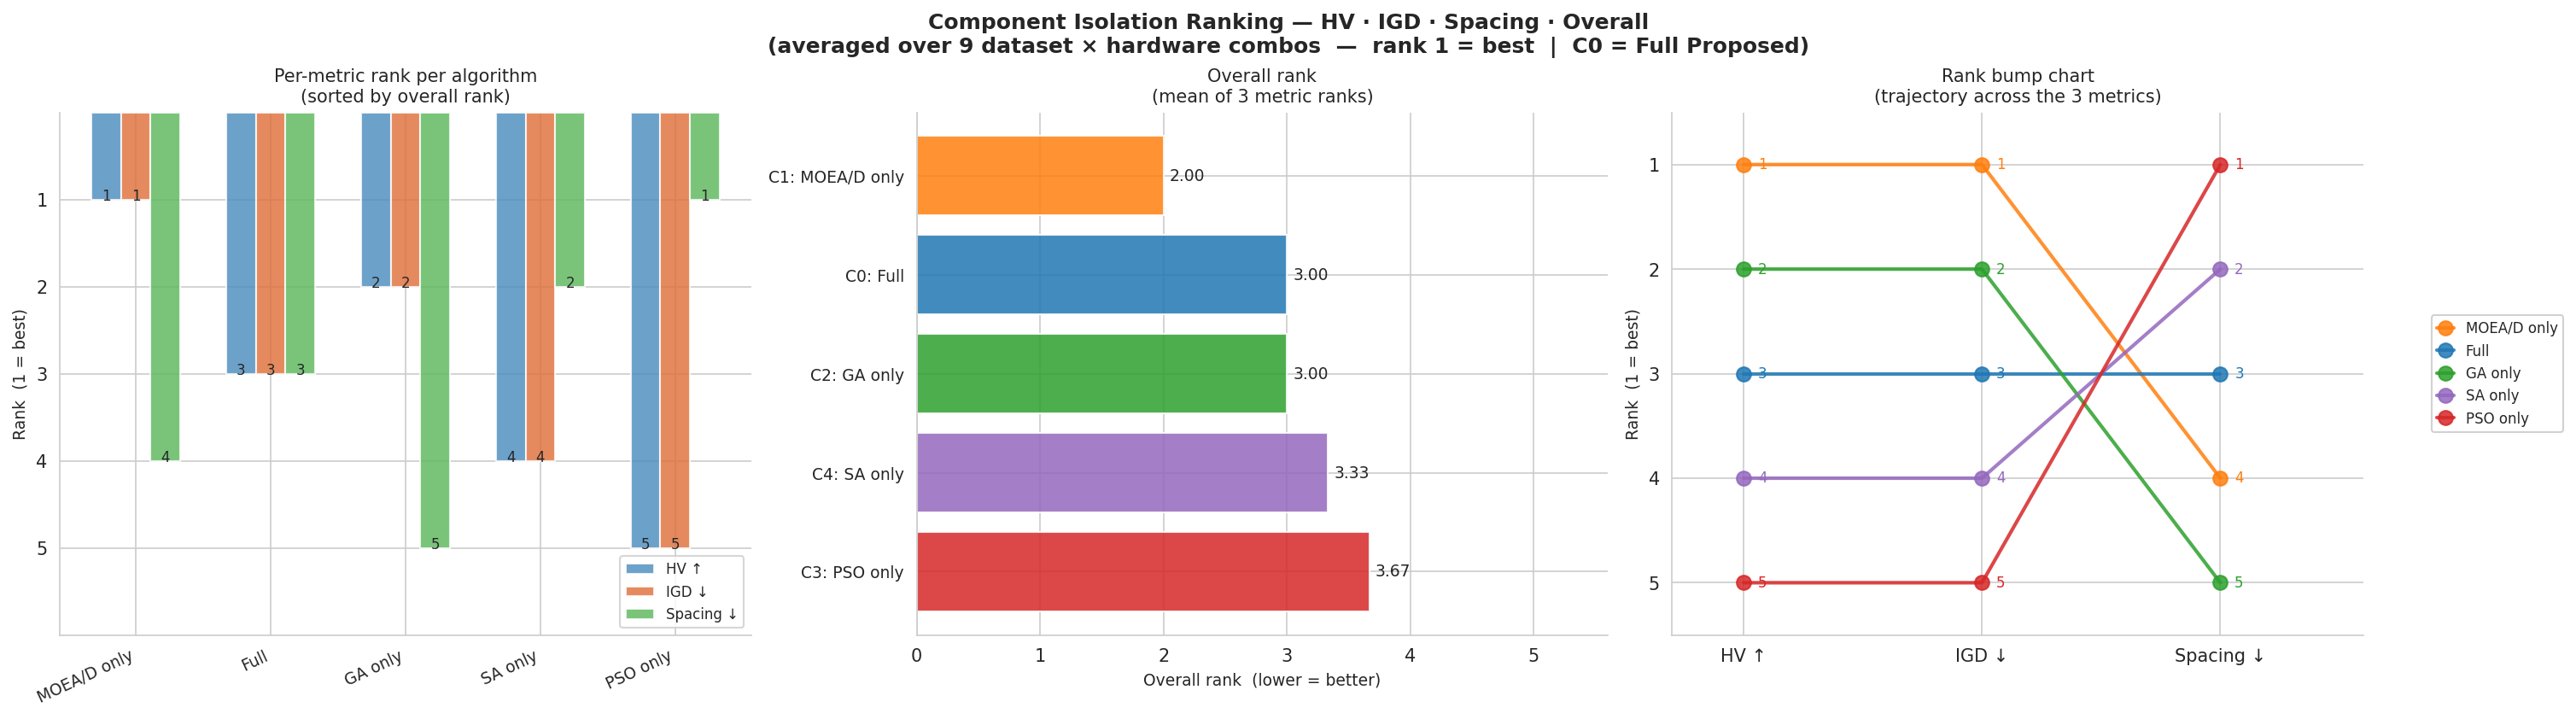

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/component_ablation/component_overall_ranking.pdf


In [11]:
# ── Cell 11: Ranking visualisation ────────────────────────────────────────────
#
# Panel A – grouped bar chart: per-metric rank per algorithm (sorted by overall)
# Panel B – horizontal bar: overall rank (lower = better)
# Panel C – bump chart: rank trajectory across the three metrics

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)
fig.suptitle(
    "Component Isolation Ranking \u2014 HV \u00b7 IGD \u00b7 Spacing \u00b7 Overall\n"
    "(averaged over 9 dataset \u00d7 hardware combos  \u2014  rank 1 = best  |  C0 = Full Proposed)",
    fontsize=12, fontweight="bold",
)

metrics_rank  = ["Rank_HV", "Rank_IGD", "Rank_Spacing"]
metric_labels = ["HV \u2191", "IGD \u2193", "Spacing \u2193"]
n_exp         = len(summary)
x             = np.arange(n_exp)
w             = 0.22
bar_colors    = ["#4c8cbf", "#e0703a", "#5cb85c"]

# ── Panel A: grouped bars — rank per metric ──────────────────────────────────
ax_a = axes[0]
for i, (col, lbl, col_c) in enumerate(zip(metrics_rank, metric_labels, bar_colors)):
    bars = ax_a.bar(
        x + (i - 1) * w, summary[col].values,
        width=w, label=lbl, color=col_c, alpha=0.82, edgecolor="white",
    )
    for bar, val in zip(bars, summary[col].values):
        ax_a.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(int(val)), ha="center", va="bottom", fontsize=8,
        )
ax_a.set_xticks(x)
ax_a.set_xticklabels(summary["Short"].tolist(), fontsize=9, rotation=25, ha="right")
ax_a.set_yticks(range(1, n_exp + 1))
ax_a.set_ylabel("Rank  (1 = best)", fontsize=9)
ax_a.set_ylim(0, n_exp + 1)
ax_a.invert_yaxis()
ax_a.legend(fontsize=8, loc="lower right")
ax_a.set_title("Per-metric rank per algorithm\n(sorted by overall rank)", fontsize=10)

# ── Panel B: horizontal bar — overall rank ───────────────────────────────────
ax_b = axes[1]
y_pos         = np.arange(n_exp)
overall_ranks = summary["Rank_Overall"].values
bar_colors_exp = [COLORS[n] for n in summary["exp_name"].tolist()]
hbars = ax_b.barh(
    y_pos, overall_ranks, color=bar_colors_exp, alpha=0.85, edgecolor="white",
)
for bar, val, lbl in zip(hbars, overall_ranks, summary["Label"].tolist()):
    ax_b.text(
        val + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}", va="center", fontsize=9,
    )
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(summary["Label"].tolist(), fontsize=9)
ax_b.set_xlabel("Overall rank  (lower = better)", fontsize=9)
ax_b.set_xlim(0, n_exp + 0.6)
ax_b.invert_yaxis()
ax_b.set_title("Overall rank\n(mean of 3 metric ranks)", fontsize=10)

# ── Panel C: bump chart — rank trajectory across 3 metrics ───────────────────
ax_c = axes[2]
metric_positions = [0, 1, 2]

for _, row in summary.iterrows():
    name  = row["exp_name"]
    short = row["Short"]
    ranks = [row["Rank_HV"], row["Rank_IGD"], row["Rank_Spacing"]]
    ax_c.plot(
        metric_positions, ranks,
        color=COLORS[name], marker="o", markersize=8,
        linewidth=2, alpha=0.85, label=short,
    )
    for mx, ry in zip(metric_positions, ranks):
        ax_c.text(
            mx + 0.06, ry, str(int(ry)),
            va="center", fontsize=8, color=COLORS[name],
        )

ax_c.set_xticks(metric_positions)
ax_c.set_xticklabels(metric_labels, fontsize=10)
ax_c.set_yticks(range(1, n_exp + 1))
ax_c.set_ylabel("Rank  (1 = best)", fontsize=9)
ax_c.set_ylim(0.5, n_exp + 0.5)
ax_c.invert_yaxis()
ax_c.set_xlim(-0.3, 2.6)
ax_c.legend(fontsize=8, loc="center right", bbox_to_anchor=(1.30, 0.5),
            framealpha=0.9, handlelength=1.2)
ax_c.set_title("Rank bump chart\n(trajectory across the 3 metrics)", fontsize=10)

save_rank = OUT_DIR / "component_overall_ranking.pdf"
plt.savefig(save_rank, bbox_inches="tight")
plt.show()
print(f"Saved: {save_rank}")